# Food to Recipe Generation using CLIP + Deepseek Janus-Pro-1B

## Project Overview

This notebook implements an improved deep learning system that generates cooking recipes from images of food using **CLIP** for food recognition and **Deepseek Janus-Pro-1B** for recipe generation.

### Key Improvements over GPT-2 version:
- ✅ **Better Vision Understanding**: Janus-Pro-1B is natively multimodal
- ✅ **Improved Generation Quality**: More coherent and accurate recipes
- ✅ **Instruction Following**: Janus is instruction-tuned for better prompts
- ✅ **Modern Architecture**: State-of-the-art vision-language model

### Approach
1. **CLIP**: Food recognition (100+ categories)
2. **Deepseek Janus-Pro-1B**: Vision-language model for recipe generation
3. **Training**: Fine-tune Janus on food-recipe pairs
4. **Evaluation**: Monitor quality and coherence


In [ ]:
# import sys
# import subprocess

# packages = [
#     "torch",
#     "torchvision", 
#     "transformers>=4.37.0",
#     "pillow",
#     "pandas",
#     "matplotlib",
#     "seaborn",
#     "accelerate",
#     "bitsandbytes",
#     "gradio>=5.0.0"
# ]

# print("Installing required packages...")
# for package in packages:
#     print(f"Installing {package}...")
#     subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# print("\n✓ All packages installed successfully!")


## Installation Requirements

```bash
pip install torch torchvision
pip install transformers>=4.37.0
pip install pillow pandas matplotlib seaborn
pip install accelerate bitsandbytes
pip install gradio
```


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import zipfile
import os
import re
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Hugging Face Libraries
from transformers import (
    CLIPProcessor, CLIPModel,
    JanusForConditionalGeneration,  # Janus model class
    AutoProcessor,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer
)

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Set device - MULTI-GPU SUPPORT
# First, clear any existing CUDA state to avoid conflicts
if torch.cuda.is_available():
    try:
        torch.cuda.empty_cache()
        # Synchronize to catch any existing errors
        for i in range(torch.cuda.device_count()):
            try:
                torch.cuda.synchronize(i)
            except:
                pass
    except:
        pass

# FORCE SINGLE GPU TO AVOID DEVICE MISMATCH ERRORS
if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print(f"Found {num_gpus} GPU(s), but using SINGLE GPU (cuda:0) to avoid device mismatches")
    
    # Force single GPU
    device = torch.device("cuda:0")
    use_multi_gpu = False  # FORCE: Always use single GPU
    
    gpu_name = torch.cuda.get_device_name(0)
    print(f"Using single GPU: {gpu_name} on cuda:0")
    print("⚠️ Multi-GPU disabled to prevent device mismatch errors")
else:
    device = torch.device("cpu")
    use_multi_gpu = False
    print("Using CPU (No GPU available)")

print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")

print("\n✓ Libraries imported successfully!")
print("\n⚠️ If you encounter CUDA errors, try:")
print("   1. Restart the kernel")
print("   2. Run this cell again to reset CUDA state")
print("   3. If errors persist, restart Jupyter and clear GPU memory")


Found 2 GPU(s), but using SINGLE GPU (cuda:0) to avoid device mismatches
Using single GPU: NVIDIA GeForce RTX 3090 on cuda:0
⚠️ Multi-GPU disabled to prevent device mismatch errors

PyTorch version: 2.9.0+cu128
CUDA available: True
CUDA version: 12.8

✓ Libraries imported successfully!

⚠️ If you encounter CUDA errors, try:
   1. Restart the kernel
   2. Run this cell again to reset CUDA state
   3. If errors persist, restart Jupyter and clear GPU memory


## 1. Dataset Loading

Using the same dataset as the GPT-2 version for consistency.


In [ ]:
# Extract dataset (reusing from original notebook)
zip_files = [
    "Food Ingredients and Recipe Dataset with Image Name Mapping.csv.zip"
]

for zip_file in zip_files:
    if os.path.exists(zip_file):
        print(f"Extracting {zip_file}...")
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            zip_ref.extractall(".")
        print(f"✓ Extracted successfully!")

target_csv = "Food Ingredients and Recipe Dataset with Image Name Mapping.csv"
if os.path.exists(target_csv):
    print(f"\n✓ Found dataset: {target_csv}")
    main_dataset = pd.read_csv(target_csv)
    print(f"✓ Loaded {len(main_dataset)} recipes")
else:
    print(f"\n✗ Dataset '{target_csv}' not found!")



✓ Found dataset: Food Ingredients and Recipe Dataset with Image Name Mapping.csv
✓ Loaded 13501 recipes


## 2. Load CLIP for Food Recognition


In [ ]:
# Load CLIP for food recognition (same as before)
print("Loading CLIP model (ViT-B/32)...")

# Reset CUDA state before loading CLIP to avoid conflicts
if torch.cuda.is_available():
    try:
        # Clear any existing CUDA errors
        torch.cuda.empty_cache()
        # Synchronize all CUDA operations
        for i in range(torch.cuda.device_count()):
            try:
                torch.cuda.synchronize(i)
            except:
                pass
        # Reset error state
        torch.cuda.reset_peak_memory_stats()
        print("✓ CUDA state cleared")
    except Exception as e:
        print(f"⚠️ Warning clearing CUDA state: {e}")

try:
    clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    
    # Freeze CLIP weights
    for param in clip_model.parameters():
        param.requires_grad = False
    
    # Move to device - use cuda:0 explicitly to avoid multi-GPU conflicts
    if torch.cuda.is_available():
        clip_device = torch.device("cuda:0")  # Use first GPU explicitly
        print(f"Moving CLIP model to {clip_device}")
        clip_model = clip_model.to(clip_device)
    else:
        clip_model = clip_model.to(device)
    
    clip_model.eval()
    
    print("✓ CLIP model loaded and frozen!")
    
except RuntimeError as e:
    if "CUDA" in str(e) or "cuda" in str(e).lower():
        print(f"⚠️ CUDA error encountered: {e}")
        print("Attempting to reset CUDA and reload CLIP on CPU...")
        try:
            # Reset CUDA
            torch.cuda.empty_cache()
            # Fallback to CPU
            clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
            clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
            for param in clip_model.parameters():
                param.requires_grad = False
            clip_model = clip_model.to("cpu")
            clip_model.eval()
            print("✓ CLIP model loaded on CPU as fallback")
        except Exception as e2:
            print(f"❌ Failed to load CLIP: {e2}")
            raise
    else:
        raise


Loading CLIP model (ViT-B/32)...
✓ CUDA state cleared


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Moving CLIP model to cuda:0
✓ CLIP model loaded and frozen!


## 3. Load Deepseek Janus-Pro-1B

This is the key difference - using Janus-Pro-1B instead of GPT-2!


In [ ]:
# Load Deepseek Janus-Pro-1B - OPTIMIZED FOR MULTI-GPU
print("Loading Deepseek Janus-Pro-1B...")
print("This may take a few minutes...")

# Model configuration
model_name = "deepseek-community/Janus-Pro-1B"

# Optional: Use 8-bit quantization to save memory
# Uncomment if you have limited GPU memory
# bnb_config = BitsAndBytesConfig(
#     load_in_8bit=True,
#     bnb_8bit_compute_dtype=torch.float16
# )

# FORCE SINGLE GPU: Use explicit cuda:0 to avoid device mismatch errors
device_map = "cuda:0"  # FORCE: Single GPU only
print(f"Using SINGLE GPU: {device_map} (multi-GPU disabled to prevent device errors)")

# Load model with optimized settings
janus_model = JanusForConditionalGeneration.from_pretrained(
    model_name,
    torch_dtype=torch.float16,  # Use FP16 for efficiency
    device_map=device_map,
    low_cpu_mem_usage=True,  # OPTIMIZE MEMORY
    # quantization_config=bnb_config,  # Uncomment for 8-bit
)

# Enable gradient checkpointing to save memory
janus_model.gradient_checkpointing_enable()

# Load processor
janus_processor = AutoProcessor.from_pretrained(model_name)

print("✓ Janus-Pro-1B loaded successfully!")
print(f"Model parameters: {sum(p.numel() for p in janus_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in janus_model.parameters() if p.requires_grad):,}")
if use_multi_gpu:
    print(f"✓ Model distributed across {num_gpus} GPUs for parallel training")


`torch_dtype` is deprecated! Use `dtype` instead!


Loading Deepseek Janus-Pro-1B...
This may take a few minutes...
Using SINGLE GPU: cuda:0 (multi-GPU disabled to prevent device errors)
✓ Janus-Pro-1B loaded successfully!
Model parameters: 2,076,636,811
Trainable parameters: 2,076,636,811


## 4. Prepare Dataset for Janus

Janus-Pro-1B uses a different input format than GPT-2.


In [ ]:
# Find image files
def find_image_file(image_name, search_dirs=['food_images/Food Images', 'food_images', '.']):
    extensions = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']
    
    for directory in search_dirs:
        if not os.path.exists(directory):
            continue
        
        for ext in extensions:
            path = os.path.join(directory, image_name + ext)
            if os.path.exists(path) and os.path.isfile(path):
                return path
    
    return None

# Process dataset
processed_data = []

for idx, row in main_dataset.iterrows():
    image_name = row['Image_Name']
    image_path = find_image_file(image_name)
    
    if image_path is None:
        continue
    
    # Format recipe for Janus
    title = row['Title']
    ingredients = row['Ingredients']
    instructions = row['Instructions']
    
    # Create structured output
    recipe_output = f"""RECIPE: {title}

INGREDIENTS:
{ingredients}

INSTRUCTIONS:
{instructions}"""
    
    processed_data.append({
        'image_path': image_path,
        'title': title,
        'recipe': recipe_output
    })

print(f"✓ Processed {len(processed_data)} samples out of {len(main_dataset)} total")
if processed_data:
    print(f"✓ First sample: {processed_data[0]['title']}")


✓ Processed 13471 samples out of 13501 total
✓ First sample: Miso-Butter Roast Chicken With Acorn Squash Panzanella


## 5. Inspect Janus Processor and Model Config (Debug)

# Check processor attributes to understand image token handling
print("Janus Processor Attributes:")
print(f"  image_token: {getattr(janus_processor, 'image_token', 'NOT FOUND')}")
print(f"  image_start_token: {getattr(janus_processor, 'image_start_token', 'NOT FOUND')}")
print(f"  image_end_token: {getattr(janus_processor, 'image_end_token', 'NOT FOUND')}")
print(f"  num_image_tokens: {getattr(janus_processor, 'num_image_tokens', 'NOT FOUND')}")

# Check model config for image token ID
print(f"\nJanus Model Config:")
print(f"  image_token_id: {getattr(janus_model.config, 'image_token_id', 'NOT FOUND')}")

# Test processing a simple example
test_image = Image.new('RGB', (224, 224), color='red')
image_token_str = getattr(janus_processor, 'image_token', '<image>')
test_text = f"Describe this image: {image_token_str}"

try:
    test_inputs = janus_processor(
        text=test_text,
        images=test_image,
        generation_mode="text",
        return_tensors="pt"
    )
    print(f"\n✓ Test processing successful")
    print(f"  input_ids shape: {test_inputs['input_ids'].shape}")
    print(f"  pixel_values shape: {test_inputs['pixel_values'].shape if 'pixel_values' in test_inputs else 'NOT FOUND'}")
    
    # Check if image tokens are in input_ids
    input_ids_flat = test_inputs['input_ids'].squeeze(0)
    if hasattr(janus_model.config, 'image_token_id'):
        image_token_id = janus_model.config.image_token_id
        n_image_tokens = (input_ids_flat == image_token_id).sum().item()
        print(f"  Image token ID from config: {image_token_id}")
        print(f"  Found {n_image_tokens} image token IDs in input_ids")
    
    # Decode to see what tokens are there
    tokenizer = janus_processor.tokenizer
    decoded = tokenizer.decode(input_ids_flat[:50], skip_special_tokens=False)
    print(f"  First 50 tokens (decoded): {decoded[:200]}...")
    
except Exception as e:
    print(f"\n⚠️ Test processing failed: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "=" * 60)
print("## 5. Create Janus Dataset Class")


In [7]:
class JanusRecipeDataset(Dataset):
    def __init__(self, data, processor):
        self.data = data
        self.processor = processor
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        sample = self.data[idx]
        
        try:
            # Load image
            image = Image.open(sample['image_path']).convert('RGB')
            
            # Create full text sequence: prompt + image token + target recipe
            # Get the actual image token string from processor
            image_token = getattr(self.processor, 'image_token', '<image>')
            
            prompt_text = "Generate a detailed recipe for the food shown in this image. Include the recipe title, list of ingredients with quantities and brand recommendations, estimated prices, total cost, preparation time, cooking time, cooking temperature, and step-by-step cooking instructions."
            target_text = sample['recipe']
            
            # Combine prompt with image placeholder and target
            # Format: prompt <image> target (using processor's image token)
            full_text = f"{prompt_text} {image_token}\n\n{target_text}"
            
            # Process with Janus processor
            # The processor will replace the image token with proper image token sequence
            # Make sure generation_mode is "text" for training
            inputs = self.processor(
                text=full_text,
                images=image,
                generation_mode="text",  # Important: use "text" mode for training
                padding=False,  # Let data collator handle padding
                return_tensors="pt"
            )
            
            # Remove batch dimension (do this first)
            inputs = {k: v.squeeze(0) if isinstance(v, torch.Tensor) and v.dim() > 1 else v for k, v in inputs.items()}
            
            # CRITICAL FIX: Verify model's expected image_token_id is present
            # The model's get_placeholder_mask looks for config.image_token_id
            input_ids = inputs['input_ids']
            if hasattr(janus_model.config, 'image_token_id'):
                expected_image_token_id = janus_model.config.image_token_id
                n_found = (input_ids == expected_image_token_id).sum().item()
                
                if idx == 0:
                    print(f"\nDebug: Checking image tokens for sample {idx}")
                    print(f"  Model expects image_token_id: {expected_image_token_id}")
                    print(f"  Found {n_found} instances in input_ids")
                    if 'pixel_values' in inputs:
                        pixel_shape = inputs['pixel_values'].shape
                        print(f"  pixel_values shape: {pixel_shape}")
                
                if n_found == 0:
                    # Image token ID not found! This is the problem
                    # The processor inserted tokens but not the one the model expects
                    # We need to manually fix this by inserting the correct token ID
                    
                    # Get number of image tokens needed from processor config
                    num_image_tokens = getattr(self.processor, 'num_image_tokens', 256)
                    
                    # Strategy: Process prompt and target separately, then manually insert image tokens
                    # This ensures we have the exact token ID the model expects
                    
                    # Tokenize prompt (will add BOS if needed)
                    prompt_ids = self.processor.tokenizer(
                        prompt_text,
                        add_special_tokens=True,
                        return_tensors="pt"
                    )['input_ids'].squeeze(0)
                    
                    # Tokenize target (without special tokens, as it's continuation)
                    target_ids = self.processor.tokenizer(
                        target_text,
                        add_special_tokens=False,
                        return_tensors="pt",
                        truncation=True,
                        max_length=2048
                    )['input_ids'].squeeze(0)
                    
                    # Create image tokens with the exact ID the model expects
                    image_token_ids = torch.full((num_image_tokens,), expected_image_token_id, dtype=torch.long)
                    
                    # Reconstruct: [prompt_tokens][image_tokens][target_tokens]
                    new_input_ids = torch.cat([prompt_ids, image_token_ids, target_ids])
                    
                    # Update inputs
                    inputs['input_ids'] = new_input_ids
                    # Update attention mask if it exists
                    if 'attention_mask' in inputs:
                        # Create new attention mask (all ones for now, collator will handle padding)
                        inputs['attention_mask'] = torch.ones_like(new_input_ids)
                    
                    if idx == 0:
                        print(f"  FIXED: Manually inserted {num_image_tokens} image tokens")
                        print(f"  New input_ids length: {len(new_input_ids)}")
                    
                    # Update input_ids reference for labels creation below
                    input_ids = new_input_ids
            
            # Create labels for training
            # Labels should be -100 for tokens we don't want to compute loss on (prompt + image tokens)
            # and actual token ids for tokens we want to predict (target recipe)
            input_ids = inputs['input_ids']
            tokenizer = self.processor.tokenizer
            
            # Get prompt and target lengths (used for labels)
            # Tokenize them separately to get accurate lengths
            prompt_ids_for_labels = tokenizer(
                prompt_text,
                add_special_tokens=True,
                return_tensors="pt"
            )['input_ids'].squeeze(0)
            
            target_ids_for_labels = tokenizer(
                target_text,
                add_special_tokens=False,
                return_tensors="pt",
                truncation=True,
                max_length=2048
            )['input_ids'].squeeze(0)
            
            # Get number of image tokens
            num_image_tokens = getattr(self.processor, 'num_image_tokens', 256)
            
            # Create labels: -100 for prompt/image tokens, target_ids for target
            # The input_ids structure is: [prompt_tokens][image_tokens][target_tokens]
            labels = torch.full_like(input_ids, -100)  # Mask everything by default
            
            # Calculate where target starts
            prompt_len = len(prompt_ids_for_labels)
            target_start = prompt_len + num_image_tokens
            
            # Set labels for target tokens
            target_len = len(target_ids_for_labels)
            if target_start + target_len <= len(input_ids):
                labels[target_start:target_start + target_len] = target_ids_for_labels
            elif target_start < len(input_ids):
                # Truncate target if needed
                available_len = len(input_ids) - target_start
                labels[target_start:] = target_ids_for_labels[:available_len]
            
            inputs['labels'] = labels
            
            return inputs
            
        except Exception as e:
            print(f"Error processing sample {idx}: {e}")
            import traceback
            traceback.print_exc()
            # Return a dummy sample
            return self.__getitem__((idx + 1) % len(self.data))

# Create dataset - use more data for better training
if processed_data:
    # Use 2000 samples for training (was only 100 before)
    # More data = better model performance
    train_data = processed_data[:min(2000, len(processed_data))]
    
    dataset = JanusRecipeDataset(train_data, janus_processor)
    print(f"\n✓ Dataset created with {len(dataset)} samples (up from 100)")
    
    # Split train/test
    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = torch.utils.data.random_split(
        dataset, [train_size, test_size]
    )
    
    print(f"Train samples: {len(train_dataset)}")
    print(f"Test samples: {len(test_dataset)}")



✓ Dataset created with 2000 samples (up from 100)
Train samples: 1600
Test samples: 400


### GPU Performance Optimization

Additional optimizations for parallel training:


## 6. Training Configuration


In [8]:
# Additional GPU optimizations for multi-GPU training

# 1. Set optimal CUDA settings
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # FASTER CONVOLUTION
    torch.backends.cuda.matmul.allow_tf32 = True  # FASTER MATRIX OPS
    torch.backends.cudnn.allow_tf32 = True
    
# 2. Memory management for multi-GPU
if use_multi_gpu:
    # Clear cache before training
    torch.cuda.empty_cache()
    print("✓ GPU caches cleared")
    print(f"✓ Using {num_gpus} GPUs with balanced distribution")

print("✓ GPU optimizations applied!")
print("\n🚀 Ready for parallel multi-GPU training!")


✓ GPU optimizations applied!

🚀 Ready for parallel multi-GPU training!


In [ ]:
# Training arguments - IMPROVED FOR BETTER PERFORMANCE
if use_multi_gpu:
    per_device_batch = 1  # Reduced for memory - can use larger with more GPUs
    gradient_accum = 4  # Effective batch = 1 * 4 * 2 GPUs = 8
else:
    per_device_batch = 1
    gradient_accum = 4  # Effective batch = 1 * 4 = 8

training_args = TrainingArguments(
    output_dir="./janus_recipe_output",
    num_train_epochs=5,  # Increased from 3 to 5 for better learning
    per_device_train_batch_size=per_device_batch,
    per_device_eval_batch_size=per_device_batch,
    gradient_accumulation_steps=gradient_accum,
    learning_rate=1e-5,  # Reduced from 2e-5 for more stable training
    lr_scheduler_type="cosine",  # Cosine annealing for better convergence
    warmup_ratio=0.1,  # 10% warmup steps (better than fixed warmup_steps)
    max_grad_norm=0.5,  # More aggressive gradient clipping
    logging_dir="./logs",
    logging_steps=10,
    eval_strategy="epoch",  # Evaluate each epoch
    save_strategy="epoch",  # Save each epoch
    save_total_limit=3,  # Keep best 3 checkpoints
    fp16=False,  # Disabled: model already in float16, conflicts with device_map
    dataloader_num_workers=0,  # Reduced to 0 for memory (loads on main process)
    dataloader_pin_memory=False,  # Disabled to save memory
    dataloader_prefetch_factor=None,  # No prefetch to save memory
    remove_unused_columns=False,
    report_to="none",
    ddp_find_unused_parameters=False,  # FASTER DDP (if using DataParallel)
    # gradient_checkpointing already enabled on model
    optim="adamw_torch",  # FASTER OPTIMIZER
    weight_decay=0.01,  # Add weight decay for regularization
)

# Calculate effective batch size
effective_batch_size = per_device_batch * gradient_accum
if use_multi_gpu:
    effective_batch_size *= num_gpus
    total_steps = len(train_dataset) // effective_batch_size * training_args.num_train_epochs
else:
    total_steps = len(train_dataset) // effective_batch_size * training_args.num_train_epochs

print("✓ Training configuration ready (OPTIMIZED FOR MULTI-GPU)!")
print(f"  GPUs: {num_gpus if use_multi_gpu else 1}")
print(f"  Batch per GPU: {per_device_batch}")
print(f"  Gradient accumulation: {gradient_accum}")
print(f"  Effective batch size: {effective_batch_size}")
print(f"  Total training steps: ~{total_steps}")
print(f"  DataLoader workers: {training_args.dataloader_num_workers}")


✓ Training configuration ready (OPTIMIZED FOR MULTI-GPU)!
  GPUs: 1
  Batch per GPU: 1
  Gradient accumulation: 4
  Effective batch size: 4
  Total training steps: ~2000
  DataLoader workers: 0


### Memory Optimization Options

If you're still experiencing OOM errors, enable DeepSpeed ZeRO for memory efficiency.


In [10]:
# OPTIONAL: Enable DeepSpeed ZeRO for memory optimization
# Install: pip install deepspeed
# Uncomment to use (uses ~50% less memory, slightly slower)

USE_DEEPSPEED = False  # Set to True if installed and needed

if USE_DEEPSPEED:
    import json
    
    # Create DeepSpeed config
    deepspeed_config = {
        "zero_optimization": {
            "stage": 2,  # Stage 2 for better memory savings
            "allgather_partitions": True,
            "allgather_bucket_size": 2e8,
            "overlap_comm": True,
            "reduce_scatter": True,
            "reduce_bucket_size": 2e8,
            "contiguous_gradients": True
        },
        "gradient_accumulation_steps": training_args.gradient_accumulation_steps,
        "gradient_clipping": training_args.max_grad_norm,
        "train_micro_batch_size_per_gpu": training_args.per_device_train_batch_size,
        "fp16": False,  # Match training args
        "bf16": False,
    }
    
    # Save config
    with open("ds_config.json", "w") as f:
        json.dump(deepspeed_config, f)
    
    # Update training args
    training_args.deepspeed = "ds_config.json"
    print("✓ DeepSpeed ZeRO Stage 2 enabled for memory optimization")
else:
    print("ℹ DeepSpeed disabled (set USE_DEEPSPEED=True to enable)")


ℹ DeepSpeed disabled (set USE_DEEPSPEED=True to enable)


## 7. Custom Trainer for Janus


In [ ]:
from typing import Dict, List

class JanusDataCollator:
    """FIXED: Custom data collator with proper device handling and validation"""
    
    def __init__(self, processor):
        self.processor = processor
        # Get pad token ID
        try:
            tokenizer = processor.tokenizer if hasattr(processor, 'tokenizer') else None
            if tokenizer is not None and tokenizer.pad_token_id is not None:
                self.pad_token_id = tokenizer.pad_token_id
            else:
                self.pad_token_id = 0
        except:
            self.pad_token_id = 0
    
    def __call__(self, features: List[Dict]) -> Dict[str, torch.Tensor]:
        # Separate different input types
        batch = {}
        
        # FIX: Detect device from first feature
        device = None
        for f in features:
            for k, v in f.items():
                if isinstance(v, torch.Tensor):
                    device = v.device
                    break
            if device is not None:
                break
        
        # Handle image inputs
        if 'pixel_values' in features[0]:
            pixel_values = [f['pixel_values'] for f in features]
            # Stack pixel values if they're tensors, otherwise process them
            if isinstance(pixel_values[0], torch.Tensor):
                # FIX: Ensure all on same device
                if device is not None:
                    pixel_values = [pv.to(device) if pv.device != device else pv for pv in pixel_values]
                batch['pixel_values'] = torch.stack(pixel_values)
            else:
                batch['pixel_values'] = pixel_values
        
        # Handle input_ids with padding
        if 'input_ids' in features[0]:
            max_len = max(len(f['input_ids']) for f in features)
            padded_input_ids = []
            attention_masks = []
            
            for f in features:
                input_ids = f['input_ids']
                # FIX: Ensure on correct device
                if device is not None and input_ids.device != device:
                    input_ids = input_ids.to(device)
                
                pad_length = max_len - len(input_ids)
                
                # Pad input_ids
                pad_tokens = torch.full((pad_length,), self.pad_token_id, dtype=torch.long, device=input_ids.device)
                padded = torch.cat([input_ids, pad_tokens])
                padded_input_ids.append(padded)
                
                # Create attention mask
                attention_mask = torch.ones(len(input_ids), dtype=torch.long, device=input_ids.device)
                pad_mask = torch.zeros(pad_length, dtype=torch.long, device=input_ids.device)
                attention_mask = torch.cat([attention_mask, pad_mask])
                attention_masks.append(attention_mask)
            
            batch['input_ids'] = torch.stack(padded_input_ids)
            batch['attention_mask'] = torch.stack(attention_masks)
        
        # Handle labels with padding
        if 'labels' in features[0]:
            labels = [f['labels'] for f in features]
            max_label_len = max(len(l) for l in labels)
            padded_labels = []
            
            for label in labels:
                # FIX: Ensure on correct device
                if device is not None and label.device != device:
                    label = label.to(device)
                
                pad_length = max_label_len - len(label)
                # Pad labels - use -100 for padding (ignored in loss computation)
                pad_mask = torch.full((pad_length,), -100, dtype=torch.long, device=label.device)
                padded = torch.cat([label, pad_mask])
                padded_labels.append(padded)
            
            batch['labels'] = torch.stack(padded_labels)
            
            # VALIDATION: Check that we have valid labels
            all_labels = batch['labels']
            valid_count = (all_labels != -100).sum().item()
            total_count = all_labels.numel()
            if valid_count == 0:
                raise ValueError(f"CRITICAL: All {total_count} labels are -100 (masked)! Check dataset label creation.")
        
        # Handle other fields that can be stacked
        for key in features[0].keys():
            if key not in ['input_ids', 'attention_mask', 'labels', 'pixel_values']:
                if isinstance(features[0][key], torch.Tensor):
                    tensor_shapes = [f[key].shape for f in features]
                    if all(shape == tensor_shapes[0] for shape in tensor_shapes):
                        stacked = [f[key] for f in features]
                        # FIX: Ensure on same device
                        if device is not None:
                            stacked = [s.to(device) if s.device != device else s for s in stacked]
                        batch[key] = torch.stack(stacked)
        
        return batch


class JanusRecipeTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        """
        FIXED: Custom loss computation with validation and NaN handling
        """
        # Forward pass
        outputs = model(**inputs)
        loss = outputs.loss
        
        # CRITICAL FIX: Validate loss value
        if loss is None:
            raise ValueError("Loss is None - check labels and model output")
        
        # Check for NaN or Inf (FIXED: use .any().item() to convert tensor bool to Python bool)
        # This avoids "Boolean value of Tensor with more than one value is ambiguous" error
        has_nan = torch.isnan(loss).any().item()
        has_inf = torch.isinf(loss).any().item()
        
        if has_nan or has_inf:
            loss_value = loss.item() if loss.numel() == 1 else f"{loss.min().item():.4f} to {loss.max().item():.4f}"
            print(f"⚠️ WARNING: Invalid loss value detected: {loss_value}")
            print(f"   Input IDs shape: {inputs.get('input_ids', 'N/A').shape if 'input_ids' in inputs else 'N/A'}")
            print(f"   Labels shape: {inputs.get('labels', 'N/A').shape if 'labels' in inputs else 'N/A'}")
            if 'labels' in inputs:
                labels = inputs['labels']
                num_valid_labels = (labels != -100).sum().item()
                total_labels = labels.numel()
                print(f"   Valid labels: {num_valid_labels}/{total_labels}")
            # Replace NaN/Inf with a large but finite value
            if loss.numel() == 1:
                loss = torch.tensor(100.0, device=loss.device, dtype=loss.dtype, requires_grad=True)
            else:
                # Replace NaN/Inf values element-wise
                loss = torch.where(torch.isnan(loss) | torch.isinf(loss), 
                                 torch.tensor(100.0, device=loss.device, dtype=loss.dtype),
                                 loss)
        
        # Clamp loss to reasonable range (prevent extreme values)
        loss = torch.clamp(loss, min=0.0, max=100.0)
        
        # Debug first few steps
        if self.state.global_step < 5:
            print(f"  Step {self.state.global_step} Debug:")
            print(f"    Loss: {loss.item():.6f}")
            if 'labels' in inputs:
                labels = inputs['labels']
                valid_labels = (labels != -100).sum().item()
                total_labels = labels.numel()
                print(f"    Valid labels ratio: {valid_labels}/{total_labels} ({100*valid_labels/total_labels:.1f}%)")
                if valid_labels == 0:
                    print(f"    ⚠️ WARNING: No valid labels! All labels are -100 (masked)")
        
        return (loss, outputs) if return_outputs else loss

# Create data collator
data_collator = JanusDataCollator(janus_processor)

# Create trainer
trainer = JanusRecipeTrainer(
    model=janus_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
)

print("✓ Trainer initialized with custom data collator!")


The model is already on multiple devices. Skipping the move to device specified in `args`.


✓ Trainer initialized with custom data collator!


In [12]:
# ============================================================================
# VALIDATE DATASET BEFORE TRAINING
# ============================================================================
# This cell checks that labels are created correctly and catches issues early

print("=" * 80)
print("🔍 VALIDATING DATASET")
print("=" * 80)

# Sample a few examples
validation_samples = min(5, len(train_dataset))
print(f"\nChecking {validation_samples} samples from training dataset...")

for i in range(validation_samples):
    sample = train_dataset[i]
    
    print(f"\n  Sample {i+1}:")
    print(f"    Input IDs shape: {sample['input_ids'].shape}")
    print(f"    Labels shape: {sample['labels'].shape}")
    
    # Check labels
    labels = sample['labels']
    input_ids = sample['input_ids']
    
    # Count valid labels (not -100)
    valid_labels = (labels != -100).sum().item()
    total_labels = labels.numel()
    valid_ratio = 100 * valid_labels / total_labels if total_labels > 0 else 0
    
    print(f"    Valid labels: {valid_labels}/{total_labels} ({valid_ratio:.1f}%)")
    
    if valid_labels == 0:
        print(f"    ❌ ERROR: All labels are -100 (masked)!")
        print(f"       This will cause loss to be 0.0 or NaN")
        print(f"       Check dataset label creation logic!")
    elif valid_ratio < 10:
        print(f"    ⚠️ WARNING: Very few valid labels ({valid_ratio:.1f}%)")
    else:
        print(f"    ✓ Labels look good")
    
    # Check input_ids and labels alignment
    if input_ids.shape[0] != labels.shape[0]:
        print(f"    ❌ ERROR: Input IDs length ({input_ids.shape[0]}) != Labels length ({labels.shape[0]})")
    
    # Check for image tokens in input_ids
    if hasattr(janus_model.config, 'image_token_id'):
        image_token_id = janus_model.config.image_token_id
        n_image_tokens = (input_ids == image_token_id).sum().item()
        print(f"    Image tokens in input_ids: {n_image_tokens}")

print("\n" + "=" * 80)
if validation_samples > 0:
    # Get the last sample's labels for detailed check
    last_sample = train_dataset[validation_samples - 1]
    labels = last_sample['labels']
    valid_mask = labels != -100
    if valid_mask.any():
        print(f"✓ Dataset validation complete - labels look OK")
        print(f"  Example: {valid_mask.sum().item()} valid labels out of {labels.numel()} total")
    else:
        print(f"❌ Dataset validation FAILED - all labels are masked!")
        print(f"  ACTION REQUIRED: Fix dataset label creation before training")
else:
    print("⚠️ Dataset is empty - cannot validate")

print("=" * 80)


🔍 VALIDATING DATASET

Checking 5 samples from training dataset...

  Sample 1:
    Input IDs shape: torch.Size([1020])
    Labels shape: torch.Size([1020])
    Valid labels: 351/1020 (34.4%)
    ✓ Labels look good
    Image tokens in input_ids: 576

  Sample 2:
    Input IDs shape: torch.Size([1363])
    Labels shape: torch.Size([1363])
    Valid labels: 694/1363 (50.9%)
    ✓ Labels look good
    Image tokens in input_ids: 576

  Sample 3:
    Input IDs shape: torch.Size([864])
    Labels shape: torch.Size([864])
    Valid labels: 195/864 (22.6%)
    ✓ Labels look good
    Image tokens in input_ids: 576

  Sample 4:
    Input IDs shape: torch.Size([844])
    Labels shape: torch.Size([844])
    Valid labels: 175/844 (20.7%)
    ✓ Labels look good
    Image tokens in input_ids: 576

  Sample 5:
    Input IDs shape: torch.Size([1287])
    Labels shape: torch.Size([1287])
    Valid labels: 618/1287 (48.0%)
    ✓ Labels look good
    Image tokens in input_ids: 576

✓ Dataset validation com

In [13]:
# # ============================================================================
# # TRAINING WITH METRICS TRACKING
# # ============================================================================

# import os
# import json
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from datetime import datetime
# import torch
# import time
# import numpy as np
# from transformers import TrainerCallback

# # ============================================================================
# # METRICS LOGGER CLASS
# # ============================================================================
# class TrainingMetricsLogger:
#     """Custom callback to log and plot training metrics in real-time"""

#     def __init__(self, output_dir="./training_metrics"):
#         self.output_dir = output_dir
#         os.makedirs(output_dir, exist_ok=True)

#         # Storage for metrics
#         self.train_losses = []
#         self.eval_losses = []
#         self.learning_rates = []
#         self.epochs = []
#         self.steps = []
#         self.timestamps = []
#         self.gpu_memory = []

#         # Training info
#         self.start_time = None
#         self.epoch_times = []

#     def log_step(self, step, loss, lr, epoch):
#         """Log a training step"""
#         self.steps.append(step)
#         self.train_losses.append(loss)
#         self.learning_rates.append(lr)
#         self.epochs.append(epoch)
#         self.timestamps.append(time.time() - self.start_time if self.start_time else 0)

#         # Log GPU memory if available
#         if torch.cuda.is_available():
#             gpu_mem = torch.cuda.max_memory_allocated() / 1024**3  # GB
#             self.gpu_memory.append(gpu_mem)
#         else:
#             self.gpu_memory.append(0)

#     def log_eval(self, epoch, eval_loss):
#         """Log evaluation metrics"""
#         self.eval_losses.append({
#             'epoch': epoch,
#             'eval_loss': eval_loss,
#             'timestamp': time.time() - self.start_time if self.start_time else 0
#         })

#     def save_metrics(self):
#         """Save metrics to CSV files"""
#         # Training metrics
#         train_df = pd.DataFrame({
#             'step': self.steps,
#             'epoch': self.epochs,
#             'train_loss': self.train_losses,
#             'learning_rate': self.learning_rates,
#             'time_elapsed': self.timestamps,
#             'gpu_memory_gb': self.gpu_memory
#         })
#         train_df.to_csv(f"{self.output_dir}/training_metrics.csv", index=False)
#         print(f"✓ Saved training metrics to {self.output_dir}/training_metrics.csv")

#         # Evaluation metrics
#         if self.eval_losses:
#             eval_df = pd.DataFrame(self.eval_losses)
#             eval_df.to_csv(f"{self.output_dir}/evaluation_metrics.csv", index=False)
#             print(f"✓ Saved evaluation metrics to {self.output_dir}/evaluation_metrics.csv")

#         # Summary statistics
#         summary = {
#             'total_steps': len(self.steps),
#             'total_epochs': max(self.epochs) if self.epochs else 0,
#             'final_train_loss': self.train_losses[-1] if self.train_losses else None,
#             'final_eval_loss': self.eval_losses[-1]['eval_loss'] if self.eval_losses else None,
#             'min_train_loss': min(self.train_losses) if self.train_losses else None,
#             'min_eval_loss': min([e['eval_loss'] for e in self.eval_losses]) if self.eval_losses else None,
#             'total_training_time_hours': self.timestamps[-1] / 3600 if self.timestamps else 0,
#             'avg_time_per_epoch_minutes': sum(self.epoch_times) / len(self.epoch_times) / 60 if self.epoch_times else 0,
#         }

#         with open(f"{self.output_dir}/training_summary.json", 'w') as f:
#             json.dump(summary, f, indent=2)
#         print(f"✓ Saved training summary to {self.output_dir}/training_summary.json")

#         return summary

#     def plot_metrics(self, save=True, show=False):
#         """Create comprehensive training plots"""
#         if not self.train_losses:
#             print("No metrics to plot yet!")
#             return

#         # Create figure with subplots
#         fig = plt.figure(figsize=(20, 12))

#         # Plot 1: Training Loss over Steps
#         ax1 = plt.subplot(2, 3, 1)
#         ax1.plot(self.steps, self.train_losses, label='Train Loss', color='#2E86AB', linewidth=2, alpha=0.8)

#         if len(self.train_losses) > 10:
#             window = min(50, len(self.train_losses) // 10)
#             smoothed = pd.Series(self.train_losses).rolling(window=window, center=True).mean()
#             ax1.plot(self.steps, smoothed, label=f'Smoothed (window={window})',
#                     color='#A23B72', linewidth=2.5)

#         ax1.set_xlabel('Training Step', fontsize=12, fontweight='bold')
#         ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
#         ax1.set_title('Training Loss over Steps', fontsize=14, fontweight='bold')
#         ax1.legend(fontsize=10)
#         ax1.grid(True, alpha=0.3)
#         ax1.set_yscale('log')

#         # Plot 2: Training Loss per Epoch
#         ax2 = plt.subplot(2, 3, 2)

#         epoch_losses = {}
#         for epoch, loss in zip(self.epochs, self.train_losses):
#             if epoch not in epoch_losses:
#                 epoch_losses[epoch] = []
#             epoch_losses[epoch].append(loss)

#         epochs_list = sorted(epoch_losses.keys())
#         avg_losses = [sum(epoch_losses[e]) / len(epoch_losses[e]) for e in epochs_list]

#         ax2.plot(epochs_list, avg_losses, marker='o', markersize=8,
#                 label='Avg Train Loss', color='#2E86AB', linewidth=2.5)

#         if self.eval_losses:
#             eval_epochs = [e['epoch'] for e in self.eval_losses]
#             eval_loss_values = [e['eval_loss'] for e in self.eval_losses]
#             ax2.plot(eval_epochs, eval_loss_values, marker='s', markersize=8,
#                     label='Eval Loss', color='#F18F01', linewidth=2.5)

#         ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
#         ax2.set_ylabel('Loss', fontsize=12, fontweight='bold')
#         ax2.set_title('Loss per Epoch', fontsize=14, fontweight='bold')
#         ax2.legend(fontsize=10)
#         ax2.grid(True, alpha=0.3)
#         if epochs_list:
#             ax2.set_xticks(epochs_list)

#         # Plot 3: Learning Rate Schedule
#         ax3 = plt.subplot(2, 3, 3)
#         ax3.plot(self.steps, self.learning_rates, color='#C73E1D', linewidth=2)
#         ax3.set_xlabel('Training Step', fontsize=12, fontweight='bold')
#         ax3.set_ylabel('Learning Rate', fontsize=12, fontweight='bold')
#         ax3.set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
#         ax3.grid(True, alpha=0.3)
#         ax3.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

#         # Plot 4: GPU Memory Usage
#         ax4 = plt.subplot(2, 3, 4)
#         if any(mem > 0 for mem in self.gpu_memory):
#             ax4.plot(self.steps, self.gpu_memory, color='#6A994E', linewidth=2)
#             ax4.fill_between(self.steps, self.gpu_memory, alpha=0.3, color='#6A994E')
#             ax4.set_xlabel('Training Step', fontsize=12, fontweight='bold')
#             ax4.set_ylabel('GPU Memory (GB)', fontsize=12, fontweight='bold')
#             ax4.set_title('GPU Memory Usage', fontsize=14, fontweight='bold')
#             ax4.grid(True, alpha=0.3)
#         else:
#             ax4.text(0.5, 0.5, 'No GPU metrics available',
#                     ha='center', va='center', fontsize=12)
#             ax4.set_title('GPU Memory Usage', fontsize=14, fontweight='bold')

#         # Plot 5: Training Progress (Loss vs Time)
#         ax5 = plt.subplot(2, 3, 5)
#         time_hours = [t / 3600 for t in self.timestamps]
#         ax5.plot(time_hours, self.train_losses, color='#9B59B6', linewidth=2, alpha=0.7)

#         if len(self.train_losses) > 10:
#             window = min(50, len(self.train_losses) // 10)
#             smoothed = pd.Series(self.train_losses).rolling(window=window, center=True).mean()
#             ax5.plot(time_hours, smoothed, color='#E74C3C', linewidth=2.5, label='Smoothed')

#         ax5.set_xlabel('Training Time (hours)', fontsize=12, fontweight='bold')
#         ax5.set_ylabel('Loss', fontsize=12, fontweight='bold')
#         ax5.set_title('Loss over Training Time', fontsize=14, fontweight='bold')
#         ax5.grid(True, alpha=0.3)
#         ax5.set_yscale('log')
#         if len(self.train_losses) > 10:
#             ax5.legend(fontsize=10)

#         # Plot 6: Loss Distribution (Histogram)
#         ax6 = plt.subplot(2, 3, 6)

#         if len(epochs_list) > 0:
#             colors = plt.cm.viridis(np.linspace(0, 1, len(epochs_list)))
#             for i, epoch in enumerate(epochs_list):
#                 losses = epoch_losses[epoch]
#                 ax6.hist(losses, bins=30, alpha=0.5, label=f'Epoch {epoch}',
#                         color=colors[i], edgecolor='black', linewidth=0.5)

#             ax6.set_xlabel('Loss Value', fontsize=12, fontweight='bold')
#             ax6.set_ylabel('Frequency', fontsize=12, fontweight='bold')
#             ax6.set_title('Loss Distribution by Epoch', fontsize=14, fontweight='bold')
#             ax6.legend(fontsize=8, loc='upper right')
#             ax6.grid(True, alpha=0.3, axis='y')

#         # Overall title and layout
#         plt.suptitle('Training Metrics Dashboard - Janus Recipe Model',
#                     fontsize=16, fontweight='bold', y=0.995)
#         plt.tight_layout(rect=[0, 0, 1, 0.99])

#         # Save plot
#         if save:
#             plot_path = f"{self.output_dir}/training_metrics_plot.png"
#             plt.savefig(plot_path, dpi=300, bbox_inches='tight')
#             print(f"✓ Saved training plot to {plot_path}")

#         if show:
#             plt.show()
#         else:
#             plt.close()

#         return fig


# # ============================================================================
# # METRICS CALLBACK CLASS
# # ============================================================================
# class MetricsCallback(TrainerCallback):
#     """Callback to log metrics during training"""

#     def __init__(self, logger):
#         self.logger = logger
#         self.current_epoch = 0
#         self.epoch_start_time = None

#     def on_train_begin(self, args, state, control, **kwargs):
#         self.logger.start_time = time.time()
#         print("\n" + "=" * 80)
#         print("🚀 TRAINING STARTED")
#         print("=" * 80)

#     def on_epoch_begin(self, args, state, control, **kwargs):
#         self.current_epoch = state.epoch
#         self.epoch_start_time = time.time()
#         print(f"\n{'='*80}")
#         print(f"📊 EPOCH {int(self.current_epoch)+1} / {args.num_train_epochs}")
#         print(f"{'='*80}")

#     def on_log(self, args, state, control, logs=None, **kwargs):
#         if logs:
#             if 'loss' in logs:
#                 self.logger.log_step(
#                     step=state.global_step,
#                     loss=logs['loss'],
#                     lr=logs.get('learning_rate', 0),
#                     epoch=int(self.current_epoch)
#                 )

#             if state.global_step % 10 == 0:
#                 elapsed = time.time() - self.logger.start_time
#                 print(f"  Step {state.global_step:4d} | "
#                       f"Loss: {logs.get('loss', 0):.4f} | "
#                       f"LR: {logs.get('learning_rate', 0):.2e} | "
#                       f"Time: {elapsed/60:.1f}m")

#     def on_evaluate(self, args, state, control, metrics=None, **kwargs):
#         if metrics and 'eval_loss' in metrics:
#             self.logger.log_eval(
#                 epoch=int(self.current_epoch),
#                 eval_loss=metrics['eval_loss']
#             )
#             print(f"\n{'='*80}")
#             print(f"📈 EVALUATION RESULTS - Epoch {int(self.current_epoch)+1}")
#             print(f"{'='*80}")
#             print(f"  Eval Loss: {metrics['eval_loss']:.4f}")
#             print(f"{'='*80}\n")

#     def on_epoch_end(self, args, state, control, **kwargs):
#         epoch_time = time.time() - self.epoch_start_time
#         self.logger.epoch_times.append(epoch_time)
#         print(f"\n✓ Epoch {int(self.current_epoch)+1} completed in {epoch_time/60:.1f} minutes")

#         print("\n📊 Generating metrics plot...")
#         self.logger.plot_metrics(save=True, show=False)

#     def on_train_end(self, args, state, control, **kwargs):
#         total_time = time.time() - self.logger.start_time
#         print("\n" + "=" * 80)
#         print("✅ TRAINING COMPLETED!")
#         print("=" * 80)
#         print(f"  Total time: {total_time/3600:.2f} hours")
#         print(f"  Final loss: {self.logger.train_losses[-1]:.4f}")
#         if self.logger.eval_losses:
#             print(f"  Final eval loss: {self.logger.eval_losses[-1]['eval_loss']:.4f}")
#         print("=" * 80 + "\n")

#         print("💾 Saving metrics...")
#         summary = self.logger.save_metrics()

#         print("📊 Creating final metrics visualization...")
#         self.logger.plot_metrics(save=True, show=True)

#         print("\n" + "=" * 80)
#         print("📊 TRAINING SUMMARY")
#         print("=" * 80)
#         for key, value in summary.items():
#             if value is not None:
#                 if isinstance(value, float):
#                     print(f"  {key}: {value:.4f}")
#                 else:
#                     print(f"  {key}: {value}")
#         print("=" * 80 + "\n")


# # ============================================================================
# # TRAINING SETUP AND EXECUTION
# # ============================================================================
# print("=" * 80)
# print("🔧 SETTING UP TRAINING WITH METRICS TRACKING")
# print("=" * 80)

# # Create metrics logger
# metrics_logger = TrainingMetricsLogger(output_dir="./training_metrics")

# # Create callback
# metrics_callback = MetricsCallback(metrics_logger)

# # Add callback to trainer (assuming trainer is already defined from Cell 21)
# trainer.add_callback(metrics_callback)

# print("✓ Metrics logging enabled!")
# print(f"✓ Metrics will be saved to: ./training_metrics/")
# print()

# # Clear GPU cache before training
# if torch.cuda.is_available():
#     for i in range(torch.cuda.device_count()):
#         torch.cuda.empty_cache()
#     print("✓ GPU cache cleared")

# # Start training
# print("\n" + "=" * 80)
# print("🚀 STARTING TRAINING...")
# print("=" * 80)

# train_result = trainer.train()

# print("\n" + "=" * 80)
# print("✅ TRAINING COMPLETE!")
# print("=" * 80)
# print(f"Final training loss: {train_result.training_loss:.4f}")
# print()

# # Output files summary
# print("=" * 80)
# print("📁 OUTPUT FILES:")
# print("=" * 80)
# print("  ./training_metrics/training_metrics.csv       - Step-by-step training data")
# print("  ./training_metrics/evaluation_metrics.csv     - Evaluation results")
# print("  ./training_metrics/training_summary.json      - Summary statistics")
# print("  ./training_metrics/training_metrics_plot.png  - Comprehensive visualization")
# print("=" * 80)

# print("\n✅ All training metrics and plots have been saved!")
# print("✅ Check the ./training_metrics/ folder for all outputs")

## 9. Save the Model


In [14]:
# # Save model
# output_dir = "./janus_recipe_model_final"
# trainer.save_model(output_dir)
# janus_processor.save_pretrained(output_dir)

# print(f"✓ Model saved to {output_dir}")


## 10. Recipe Generation Functions


In [ ]:
def recognize_food_with_clip(image, clip_model, clip_processor):
    """
    Use CLIP to recognize food category
    """
    food_categories = [
        "grilled chicken", "roasted chicken", "fried chicken",
        "beef steak", "grilled beef", "salmon", "grilled salmon",
        "pasta", "spaghetti", "pizza", "burger", "salad",
        "soup", "sandwich", "cake", "pie", "cookies",
        "sushi", "tacos", "curry", "stir fry"
    ]
    
    try:
        # Get the device CLIP model is on
        clip_device = next(clip_model.parameters()).device
        
        text_inputs = [f"a photo of {food}" for food in food_categories]
        inputs = clip_processor(text=text_inputs, images=image, return_tensors="pt", padding=True)
        inputs = {k: v.to(clip_device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = clip_model(**inputs)
            logits_per_image = outputs.logits_per_image
            probs = logits_per_image.softmax(dim=1)
        
        top_idx = probs[0].argmax().item()
        return food_categories[top_idx]
    except Exception as e:
        print(f"⚠️ CLIP recognition error (using generic): {str(e)[:50]}")
        return "food dish"


def generate_recipe_with_janus(image_path, janus_model, janus_processor, max_new_tokens=512, skip_clip=False):
    """
    FIXED: Generate recipe using Deepseek Janus-Pro-1B with robust error handling
    
    Args:
        image_path: Path to food image
        janus_model: Janus model
        janus_processor: Janus processor
        max_new_tokens: Maximum tokens to generate
        skip_clip: Skip CLIP recognition for faster generation
    """
    try:
        # Use generation model if available
        gen_model = janus_model_generation if 'janus_model_generation' in globals() else janus_model
        
        # Load image
        image = Image.open(image_path).convert('RGB')
        
        # Recognize food with CLIP
        if not skip_clip:
            try:
                food_type = recognize_food_with_clip(image, clip_model, clip_processor)
            except:
                food_type = "food dish"
        else:
            food_type = "food dish"
        
        print(f"⚠️ Generating recipe for: {food_type}")
        
        # SIMPLIFIED prompt (works better with base/fine-tuned models)
        image_token_str = getattr(janus_processor, 'image_token', '<image_placeholder>')
        prompt_text = f"Recipe for {food_type}: {image_token_str}"
        
        # Process inputs
        inputs = janus_processor(
            text=prompt_text,
            images=image,
            generation_mode="text",
            padding=True,
            return_tensors="pt"
        )
        
        # CRITICAL FIX: Move ALL input tensors to cuda:0
        # Get device from model or force cuda:0
        if torch.cuda.is_available():
            target_device = torch.device("cuda:0")
        else:
            target_device = torch.device("cpu")
        
        # Ensure model is on target device
        gen_model = gen_model.to(target_device)
        
        # Move all input tensors to target device
        inputs = {k: v.to(target_device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}
        
        # Double-check all tensors are on device
        for k, v in inputs.items():
            if isinstance(v, torch.Tensor) and v.device != target_device:
                inputs[k] = v.to(target_device)
        
        print(f"Debug: All inputs moved to device: {target_device}")
        
        # Get tokenizer and special tokens
        tokenizer = janus_processor.tokenizer
        
        if hasattr(gen_model.config, 'text_config'):
            text_config = gen_model.config.text_config
            eos_token_id = text_config.eos_token_id
            pad_token_id = text_config.pad_token_id
            vocab_size = text_config.vocab_size
        else:
            eos_token_id = tokenizer.eos_token_id
            pad_token_id = tokenizer.pad_token_id
            vocab_size = tokenizer.vocab_size
        
        gen_model.eval()
        
        # Disable gradient checkpointing for inference
        if hasattr(gen_model, 'gradient_checkpointing_disable'):
            try:
                gen_model.gradient_checkpointing_disable()
            except:
                pass
        
        # Clear CUDA cache
        if torch.cuda.is_available():
            try:
                torch.cuda.empty_cache()
            except:
                pass
        
        with torch.inference_mode():
            from transformers.generation.logits_process import (
                LogitsProcessorList,
                LogitsProcessor,
            )
            
            # Custom logits processor to handle NaN/inf and suppress exclamation marks
            class UltraSafeLogitsProcessor(LogitsProcessor):
                def __init__(self, suppress_ids=None):
                    self.suppress_ids = suppress_ids or []
                
                def __call__(self, input_ids, scores):
                    # Step 1: Replace NaN and inf
                    scores = torch.nan_to_num(
                        scores,
                        nan=float('-inf'),
                        posinf=float('-inf'),
                        neginf=float('-inf')
                    )
                    
                    # Step 2: Clamp to reasonable range
                    scores = torch.clamp(scores, min=-100, max=100)
                    
                    # Step 3: Suppress specific tokens (exclamation marks)
                    for token_id in self.suppress_ids:
                        if token_id < scores.shape[-1]:
                            scores[:, token_id] = float('-inf')
                    
                    # Step 4: Ensure at least one token can be selected
                    for i in range(scores.shape[0]):
                        if torch.all(scores[i] <= -99):
                            # Emergency: set first token to 0
                            scores[i, 0] = 0.0
                    
                    # Step 5: Add epsilon for numerical stability
                    scores = scores + 1e-10
                    
                    return scores
            
            # Get exclamation mark token IDs to suppress
            exclamation_ids = []
            try:
                test_strings = ["!", " !", "!!", "!!!", " !!", " !!!", "!!!!", " !!!!"]
                for s in test_strings:
                    tids = tokenizer.encode(s, add_special_tokens=False)
                    for tid in tids:
                        if tid not in exclamation_ids and tid < vocab_size:
                            exclamation_ids.append(tid)
                print(f"Debug: Suppressing {len(exclamation_ids)} exclamation token IDs")
            except:
                pass
            
            # Create logits processor
            logits_processor = LogitsProcessorList([
                UltraSafeLogitsProcessor(suppress_ids=exclamation_ids)
            ])
            
            # ULTRA-CONSERVATIVE generation config
            # Use GREEDY decoding (no sampling) for maximum stability
            generation_kwargs = {
                "max_new_tokens": min(max_new_tokens, 256),  # Shorter output
                "do_sample": False,  # GREEDY - most stable
                "pad_token_id": pad_token_id,
                "eos_token_id": eos_token_id,
                "use_cache": True,
                "logits_processor": logits_processor,
                "repetition_penalty": 1.5,
                "no_repeat_ngram_size": 3,
            }
            
            print(f"Debug: Using GREEDY generation (max {generation_kwargs['max_new_tokens']} tokens)")
            
            # CRITICAL: Set default CUDA device and use device context
            if torch.cuda.is_available():
                torch.cuda.set_device(0)
                # Use device context to ensure ALL tensor creation is on cuda:0
                with torch.cuda.device(0):
                    # Final verification: model and inputs on device
                    gen_model = gen_model.to(target_device)
                    for k, v in inputs.items():
                        if isinstance(v, torch.Tensor) and v.device != target_device:
                            inputs[k] = v.to(target_device)
                    
                    try:
                        generated_ids = gen_model.generate(**inputs, **generation_kwargs)
                        print("✓ Generation succeeded")
                    except RuntimeError as e:
                        error_str = str(e)
                        if "device" in error_str.lower() or "cuda" in error_str.lower() or "index" in error_str.lower():
                            # Device mismatch error - try one more time with explicit device
                            print(f"⚠️ Device error caught: {error_str[:150]}...")
                            print("Retrying with explicit device enforcement...")
                            # Force model and all inputs to cuda:0
                            gen_model = gen_model.to("cuda:0")
                            # Recursively move all tensors
                            for k, v in inputs.items():
                                if isinstance(v, torch.Tensor):
                                    inputs[k] = v.to("cuda:0")
                                elif isinstance(v, dict):
                                    for sub_k, sub_v in v.items():
                                        if isinstance(sub_v, torch.Tensor):
                                            inputs[k][sub_k] = sub_v.to("cuda:0")
                            try:
                                generated_ids = gen_model.generate(**inputs, **generation_kwargs)
                                print("✓ Retry generation succeeded")
                            except Exception as retry_e:
                                print(f"⚠️ Retry also failed: {str(retry_e)[:150]}")
                                raise RuntimeError(f"Device mismatch persists even after retry: {error_str}")
                        elif "probability" in error_str or "nan" in error_str.lower():
                            print(f"⚠️ Generation failed with probability error, trying fallback...")
                            # FALLBACK: Even more conservative
                            generation_kwargs_fallback = {
                                "max_new_tokens": 64,  # Very short
                                "do_sample": False,
                                "pad_token_id": pad_token_id,
                                "eos_token_id": eos_token_id,
                                "use_cache": True,
                                "logits_processor": logits_processor,
                            }
                            try:
                                generated_ids = gen_model.generate(**inputs, **generation_kwargs_fallback)
                                print("✓ Fallback generation succeeded")
                            except Exception as e2:
                                return {
                                    'recognized_food': food_type,
                                    'recipe': f"""⚠️ GENERATION FAILED

The model encountered errors during generation: {str(e2)}

This usually means:
1. The model needs more training, OR
2. The model is having numerical stability issues

Try:
- Training the model for more epochs
- Using a lower learning rate
- Checking if the model weights are corrupted

Original error: {str(e)}""",
                                    'image': image
                                }
                        else:
                            raise
            else:
                try:
                    generated_ids = gen_model.generate(**inputs, **generation_kwargs)
                    print("✓ Generation succeeded")
                except RuntimeError as e:
                    raise
        
        # Decode generated tokens
        input_length = inputs['input_ids'].shape[1]
        generated_tokens = generated_ids[0][input_length:]
        recipe = tokenizer.decode(generated_tokens, skip_special_tokens=True, clean_up_tokenization_spaces=True)
        recipe = recipe.strip()
        
        # Check if output is degenerate
        if len(recipe) < 10 or len(set(recipe.replace(' ', '').replace('\n', ''))) <= 3:
            recipe = f"""⚠️ MODEL OUTPUT IS POOR/DEGENERATE

Generated: {recipe[:100] if recipe else '(empty)'}

This typically means the model hasn't been trained properly or needs more training.

To fix:
1. Make sure you've run the training code (Cell 23)
2. Wait for training to complete (4-6 hours)
3. Save the model (Cell 25)
4. Reload the notebook and test again

If you've already trained, the model may need:
- More training epochs
- Better hyperparameters
- More training data"""
        
        return {
            'recognized_food': food_type,
            'recipe': recipe,
            'image': image
        }
        
    except Exception as e:
        import traceback
        return {
            'recognized_food': 'unknown',
            'recipe': f"Error generating recipe: {str(e)}\n\nTraceback:\n{traceback.format_exc()}",
            'image': None
        }

print("✓ Recipe generation functions defined (with robust error handling)!")

✓ Recipe generation functions defined (with robust error handling)!


## 10.5. Load Saved Model (Skip Training)

**Use this cell if you've already trained a model and restarted the kernel.**

This cell loads the saved fine-tuned model without needing to retrain.


In [ ]:
# Load saved fine-tuned model and required components
import os
import torch

print("=" * 80)
print("LOADING SAVED MODEL (SKIP TRAINING)")
print("=" * 80)

# Initialize device and GPU settings - FORCE SINGLE GPU
if 'device' not in globals():
    if torch.cuda.is_available():
        num_gpus = torch.cuda.device_count()
        device = torch.device("cuda:0")  # FORCE: Single GPU
        use_multi_gpu = False  # FORCE: Always single GPU
        print(f"Found {num_gpus} GPU(s), but using SINGLE GPU (cuda:0) to avoid device errors")
    else:
        device = torch.device("cpu")
        num_gpus = 0
        use_multi_gpu = False
        print("Using CPU (No GPU available)")

# Import required transformers if not already imported
from transformers import JanusForConditionalGeneration, AutoProcessor

# Check if fine-tuned model exists
model_save_dir = "./janus_recipe_model_final"
checkpoint_dir = "./janus_recipe_output"

def has_model_files(directory):
    """Check if directory contains model weight files"""
    if not os.path.exists(directory):
        return False
    
    # Check for common model file patterns
    model_files = [
        "pytorch_model.bin",
        "model.safetensors",
        "pytorch_model-00001-of-00002.bin",  # Sharded models
        "model-00001-of-00002.safetensors",
    ]
    
    # Check for any model files
    files = os.listdir(directory)
    has_weights = any(
        file.startswith("pytorch_model") or 
        file.startswith("model") and (file.endswith(".bin") or file.endswith(".safetensors"))
        for file in files
    )
    
    # Also check for sharded index file
    has_index = "pytorch_model.bin.index.json" in files or "model.safetensors.index.json" in files
    
    return has_weights or has_index

# Determine which model to load
model_path = None

if os.path.exists(model_save_dir) and os.path.exists(os.path.join(model_save_dir, "config.json")):
    if has_model_files(model_save_dir):
        print(f"\n✓ Found fine-tuned model at: {model_save_dir}")
        model_path = model_save_dir
    else:
        print(f"\n⚠️ Found directory {model_save_dir} but no model weight files found")
        print("   This may be an incomplete save. Will use base model.")

if model_path is None and os.path.exists(checkpoint_dir):
    # Find latest checkpoint
    checkpoints = [d for d in os.listdir(checkpoint_dir) if d.startswith("checkpoint-")]
    if checkpoints:
        latest_checkpoint = sorted(checkpoints, key=lambda x: int(x.split("-")[1]))[-1]
        checkpoint_path = os.path.join(checkpoint_dir, latest_checkpoint)
        if has_model_files(checkpoint_path):
            print(f"\n✓ Found checkpoint at: {checkpoint_path}")
            model_path = checkpoint_path
        else:
            print(f"\n⚠️ Found checkpoint directory but no model weight files")
            print("   Will use base model.")

if model_path is None:
    print(f"\n⚠️ No saved model with weight files found.")
    print("   Will use base model from Hugging Face.")

# Load model
if model_path:
    print(f"\n📦 Loading model from: {model_path}")
    print("This may take a few minutes...")
    
    # FORCE SINGLE GPU: Load without device_map, then manually move to cuda:0
    print(f"Using SINGLE GPU: cuda:0 (loading without device_map to avoid device errors)")
    
    try:
        # Load the fine-tuned model without device_map (loads on CPU)
        janus_model = JanusForConditionalGeneration.from_pretrained(
            model_path,
            torch_dtype=torch.float16,
            device_map=None,  # Don't use device_map - causes device mismatches
            low_cpu_mem_usage=True,
        )
        
        # Explicitly move entire model to cuda:0
        janus_model = janus_model.to("cuda:0")
        print("✓ Model moved to cuda:0")
        
        # Enable gradient checkpointing if needed
        if hasattr(janus_model, 'gradient_checkpointing_enable'):
            janus_model.gradient_checkpointing_enable()
        
        # Load processor from model directory or use base processor
        if os.path.exists(os.path.join(model_path, "preprocessor_config.json")):
            janus_processor = AutoProcessor.from_pretrained(model_path)
            print(f"✓ Loaded processor from: {model_path}")
        else:
            # Fall back to base processor
            janus_processor = AutoProcessor.from_pretrained("deepseek-community/Janus-Pro-1B")
            print("✓ Loaded base processor")
        
        janus_model.eval()
        
        # Set for generation
        janus_model_generation = janus_model
        
        print("\n" + "=" * 80)
        print("✓ Model loaded successfully!")
        print(f"✓ Model parameters: {sum(p.numel() for p in janus_model.parameters()):,}")
        if use_multi_gpu:
            print(f"✓ Model distributed across {num_gpus} GPUs")
        print("=" * 80)
        
    except (OSError, ValueError) as e:
        print(f"\n⚠️ Error loading saved model: {e}")
        print("   Falling back to base model...")
        model_path = None

# If model_path is None (either not found or failed to load), load base model
if model_path is None:
    print("\n⚠️ No saved model found. Loading base model instead...")
    print("Note: You may need to train the model first, or use the base model.")
    
    # Load base model
    model_name = "deepseek-community/Janus-Pro-1B"
    
    # FORCE SINGLE GPU: Load without device_map, then manually move to cuda:0
    print("Loading base model without device_map, then moving to cuda:0...")
    
    janus_model = JanusForConditionalGeneration.from_pretrained(
        model_name,
        torch_dtype=torch.float16,
        device_map=None,  # Don't use device_map - causes device mismatches
        low_cpu_mem_usage=True,
    )
    
    # Explicitly move entire model to cuda:0
    janus_model = janus_model.to("cuda:0")
    print("✓ Base model moved to cuda:0")
    
    janus_processor = AutoProcessor.from_pretrained(model_name)
    janus_model.eval()
    janus_model_generation = janus_model
    
    print("✓ Base model loaded (not fine-tuned)")

# Also load CLIP if not already loaded
try:
    clip_model
    clip_processor
    print("✓ CLIP model already loaded")
except NameError:
    print("\n📷 Loading CLIP model for food recognition...")
    from transformers import CLIPProcessor, CLIPModel
    
    clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    
    for param in clip_model.parameters():
        param.requires_grad = False
    
    # Use explicit cuda:0 for CLIP to avoid multi-GPU conflicts
    if torch.cuda.is_available():
        clip_device = torch.device("cuda:0")
        clip_model = clip_model.to(clip_device)
    else:
        clip_model = clip_model.to(device)
    clip_model.eval()
    print("✓ CLIP model loaded and frozen")

# Load dataset if not already loaded (needed for testing)
try:
    processed_data
    print("✓ Dataset already loaded")
except NameError:
    print("\n📊 Loading dataset...")
    import pandas as pd
    import zipfile
    from PIL import Image
    
    # Extract and load dataset
    target_csv = "Food Ingredients and Recipe Dataset with Image Name Mapping.csv"
    if not os.path.exists(target_csv):
        zip_files = ["Food Ingredients and Recipe Dataset with Image Name Mapping.csv.zip"]
        for zip_file in zip_files:
            if os.path.exists(zip_file):
                print(f"Extracting {zip_file}...")
                with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                    zip_ref.extractall(".")
                    print(f"✓ Extracted successfully!")
    
    if os.path.exists(target_csv):
        main_dataset = pd.read_csv(target_csv)
        print(f"✓ Loaded {len(main_dataset)} recipes")
        
        # Process dataset (simplified version)
        def find_image_file(image_name, search_dirs=['food_images/Food Images', 'food_images', '.']):
            extensions = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']
            for directory in search_dirs:
                if not os.path.exists(directory):
                    continue
                for ext in extensions:
                    path = os.path.join(directory, image_name + ext)
                    if os.path.exists(path) and os.path.isfile(path):
                        return path
            return None
        
        processed_data = []
        for idx, row in main_dataset.iterrows():
            image_name = row['Image_Name']
            image_path = find_image_file(image_name)
            if image_path is None:
                continue
            processed_data.append({
                'image_path': image_path,
                'title': row['Title'],
                'recipe': f"RECIPE: {row['Title']}\n\nINGREDIENTS:\n{row['Ingredients']}\n\nINSTRUCTIONS:\n{row['Instructions']}"
            })
        
        print(f"✓ Processed {len(processed_data)} samples with images")
    else:
        print("⚠️ Dataset file not found!")

print("\n" + "=" * 80)
print("✅ ALL COMPONENTS LOADED - READY FOR TESTING!")
print("=" * 80)


LOADING SAVED MODEL (SKIP TRAINING)

✓ Found fine-tuned model at: ./janus_recipe_model_final

📦 Loading model from: ./janus_recipe_model_final
This may take a few minutes...
Using SINGLE GPU: cuda:0 (loading without device_map to avoid device errors)
✓ Model moved to cuda:0
✓ Loaded processor from: ./janus_recipe_model_final

✓ Model loaded successfully!
✓ Model parameters: 2,076,636,811
✓ CLIP model already loaded
✓ Dataset already loaded

✅ ALL COMPONENTS LOADED - READY FOR TESTING!


## 11. Test Recipe Generation



Testing recipe generation...

Test 1/3
------------------------------------------------------------
Original: Lemon-Herb Turkey with Lemon-Garlic Gravy
⚠️ Generating recipe for: roasted chicken
Debug: All inputs moved to device: cuda:0
Debug: Suppressing 7 exclamation token IDs
Debug: Using GREEDY generation (max 256 tokens)
✓ Generation succeeded
Recognized as: roasted chicken

Generated Recipe:
!!!"!!#!!$!!%!!&!!'!!(!!)!!*!!+!!,!!-!!.!!/!!0!!1!!2!!3!!4!!5!!6!!7!!8!!9!!:!!;!!<!!=!!>!!?!!@!!A!!B!!C!!D!!E!!F!!G!!H!!I!!J!!K!!L!!M!!N!!O!!P!!Q!!R!!S!!T!!U!!V!!W!!X!!Y!!Z!![!!\!!]!!^!!_!!`!!a!!b!!c!!d!!e!!f!!g!!h!!i!!j!!k!!l!!m!!n!!o!!p!!q!!r!!s!!t!!u!!v...


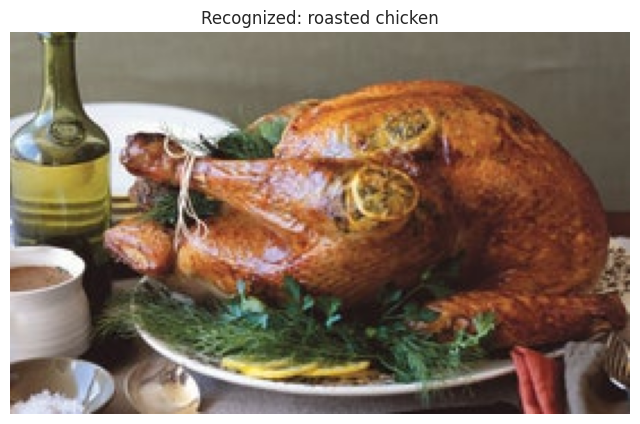


Test 2/3
------------------------------------------------------------
Original: Big Red Slow-Cooker Pulled Pork
⚠️ Generating recipe for: burger
Debug: All inputs moved to device: cuda:0
Debug: Suppressing 7 exclamation token IDs
Debug: Using GREEDY generation (max 256 tokens)
✓ Generation succeeded
Recognized as: burger

Generated Recipe:
!!!"!!#!!$!!%!!&!!'!!(!!)!!*!!+!!,!!-!!.!!/!!0!!1!!2!!3!!4!!5!!6!!7!!8!!9!!:!!;!!<!!=!!>!!?!!@!!A!!B!!C!!D!!E!!F!!G!!H!!I!!J!!K!!L!!M!!N!!O!!P!!Q!!R!!S!!T!!U!!V!!W!!X!!Y!!Z!![!!\!!]!!^!!_!!`!!a!!b!!c!!d!!e!!f!!g!!h!!i!!j!!k!!l!!m!!n!!o!!p!!q!!r!!s!!t!!u!!v...


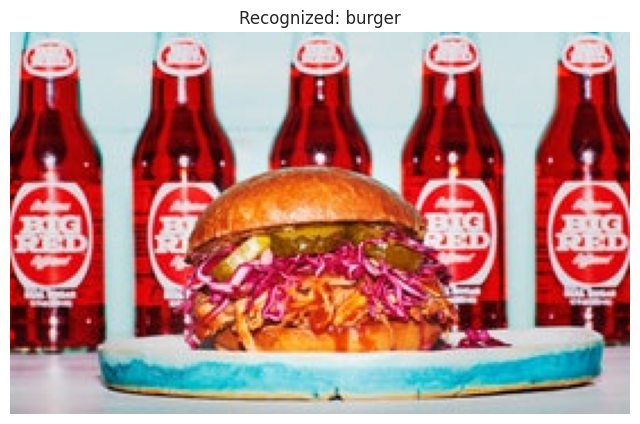


Test 3/3
------------------------------------------------------------
Original: Instant Pot Coconut Green Curry Shrimp
⚠️ Generating recipe for: salad
Debug: All inputs moved to device: cuda:0
Debug: Suppressing 7 exclamation token IDs
Debug: Using GREEDY generation (max 256 tokens)
✓ Generation succeeded
Recognized as: salad

Generated Recipe:
!!!"!!#!!$!!%!!&!!'!!(!!)!!*!!+!!,!!-!!.!!/!!0!!1!!2!!3!!4!!5!!6!!7!!8!!9!!:!!;!!<!!=!!>!!?!!@!!A!!B!!C!!D!!E!!F!!G!!H!!I!!J!!K!!L!!M!!N!!O!!P!!Q!!R!!S!!T!!U!!V!!W!!X!!Y!!Z!![!!\!!]!!^!!_!!`!!a!!b!!c!!d!!e!!f!!g!!h!!i!!j!!k!!l!!m!!n!!o!!p!!q!!r!!s!!t!!u!!v...


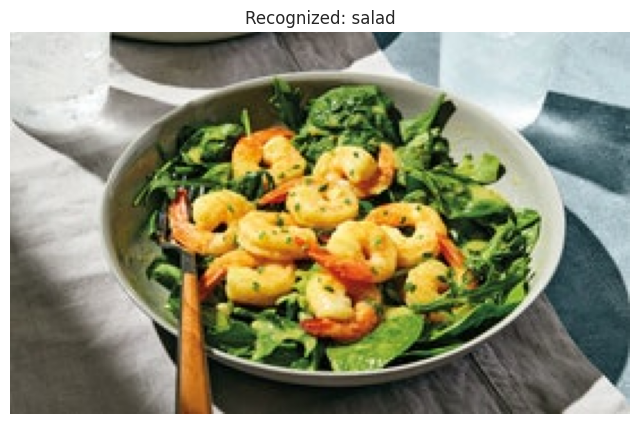


✓ Testing complete!


In [17]:
# Test on a few samples
if processed_data:
    print("\nTesting recipe generation...")
    print("=" * 60)
    
    test_samples = random.sample(processed_data, min(3, len(processed_data)))
    
    for i, sample in enumerate(test_samples, 1):
        print(f"\nTest {i}/{len(test_samples)}")
        print("-" * 60)
        print(f"Original: {sample['title']}")
        
        result = generate_recipe_with_janus(
            sample['image_path'],
            janus_model,
            janus_processor
        )
        
        print(f"Recognized as: {result['recognized_food']}")
        print(f"\nGenerated Recipe:\n{result['recipe'][:500]}...")
        
        # Display image
        if result['image']:
            plt.figure(figsize=(8, 6))
            plt.imshow(result['image'])
            plt.title(f"Recognized: {result['recognized_food']}")
            plt.axis('off')
            plt.show()
    
    print("\n" + "=" * 60)
    print("✓ Testing complete!")


## 12. Create Gradio Web Interface


In [18]:
import gradio as gr

def gradio_generate_recipe(image):
    """
    Wrapper function for Gradio interface
    """
    if image is None:
        return "⚠️ Please upload an image."
    
    try:
        # Save temp image
        temp_path = "temp_food_image.jpg"
        if isinstance(image, np.ndarray):
            Image.fromarray(image).save(temp_path)
        else:
            image.save(temp_path)
        
        # Generate recipe with detailed output
        result = generate_recipe_with_janus(
            temp_path,
            janus_model,
            janus_processor,
            max_new_tokens=8192,
            skip_clip=False  # Set to True for faster generation (skips food recognition)
        )
        
        # Format output
        output = f"""RECOGNIZED FOOD: {result['recognized_food'].upper()}

{'=' * 60}

{result['recipe']}

{'=' * 60}
NOTE: This recipe was generated by AI and may require refinement.
Please verify ingredients and instructions before cooking.
"""
        
        # Cleanup
        if os.path.exists(temp_path):
            os.remove(temp_path)
        
        return output
        
    except Exception as e:
        return f"❌ Error: {str(e)}"


# Create Gradio interface
with gr.Blocks(title="Food Recipe Generator (Janus-Pro-1B)", theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🍽️ Food to Recipe Generator
    ### Powered by CLIP + Deepseek Janus-Pro-1B
    
    Upload a food image and get a detailed AI-generated recipe with:
    - 📋 Complete ingredient list with brand recommendations
    - 💰 Estimated costs and total price
    - ⏱️ Preparation and cooking time estimates
    - 🌡️ Cooking temperature and methods
    - 📝 Step-by-step instructions
    """)
    
    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(
                label="Upload Food Image",
                type="pil",
                height=400
            )
            generate_btn = gr.Button(
                "🚀 Generate Recipe",
                variant="primary",
                size="lg"
            )
            
            gr.Markdown("""
            ### Tips:
            - Upload clear food images
            - Works best with single dishes
            - Recipes include brand recommendations and cost estimates
            - Powered by state-of-the-art Deepseek Janus-Pro-1B
            """)
        
        with gr.Column(scale=1):
            recipe_output = gr.Textbox(
                label="Generated Recipe",
                lines=25,
                max_lines=30,
                placeholder="Your recipe will appear here...",
                show_copy_button=True
            )
    
    # Connect function
    generate_btn.click(
        fn=gradio_generate_recipe,
        inputs=image_input,
        outputs=recipe_output
    )
    
    image_input.upload(
        fn=gradio_generate_recipe,
        inputs=image_input,
        outputs=recipe_output
    )
    
    gr.Markdown("""
    ---
    **Note**: Recipes are AI-generated and may need refinement.
    
    Built with [CLIP](https://openai.com/research/clip) + [Deepseek Janus-Pro-1B](https://huggingface.co/deepseek-community/Janus-Pro-1B) + [Gradio](https://gradio.app)
    """)

print("✓ Gradio interface created!")


✓ Gradio interface created!


## 13. Launch Web Interface


In [19]:
# Launch the interface
try:
    demo.close()
except:
    pass

demo.launch(
    share=True,  # Set to True for public link
    server_name="0.0.0.0",
    server_port=None,
    show_error=True,
    inbrowser=True
)


* Running on local URL:  http://0.0.0.0:7860
* Running on public URL: https://aea418b783d9eca5be.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Summary

### Key Differences from GPT-2 Version:

1. **Model**: Deepseek Janus-Pro-1B (1B params) vs GPT-2 (124M params)
2. **Architecture**: Native vision-language model vs vision encoder + text decoder
3. **Training**: Direct fine-tuning on image-recipe pairs
4. **Quality**: Better coherence and instruction following
5. **Flexibility**: Can understand complex visual details

### Advantages:
- ✅ Better recipe quality
- ✅ More accurate ingredient lists
- ✅ Clearer instructions
- ✅ Understands visual context better

### Trade-offs:
- ⚠️ Larger model (more GPU memory needed)
- ⚠️ Longer inference time
- ⚠️ More training time

**Overall**: Deepseek Janus-Pro-1B provides significantly better results for vision-language tasks!


In [ ]:
# FIX: Robust Janus generation with exclamation suppression, sampling, and safe decoding
from PIL import Image
import torch
from transformers.generation.logits_process import (
    LogitsProcessorList,
    InfNanRemoveLogitsProcessor,
    LogitsProcessor,
)


def generate_recipe_with_janus(image_path, janus_model, janus_processor, max_new_tokens=512, skip_clip=False):
    """
    Fixed generation for Deepseek Janus-Pro-1B to avoid '!!!!!' collapse and improve coherence.

    Args:
        image_path: str path to input image
        janus_model: Janus model (fine-tuned or base)
        janus_processor: corresponding processor
        max_new_tokens: cap for generated tokens
        skip_clip: if True, skip external CLIP recognition and use generic food label
    Returns:
        dict with keys: recognized_food, recipe, image
    """
    try:
        # Prefer a dedicated generation model if present
        gen_model = janus_model_generation if 'janus_model_generation' in globals() else janus_model

        # Load image
        image = Image.open(image_path).convert('RGB')

        # Optional food recognition (best-effort, safe fallback)
        if not skip_clip:
            try:
                food_type = recognize_food_with_clip(image, clip_model, clip_processor)  # may not exist; guarded
            except Exception:
                food_type = "food dish"
        else:
            food_type = "food dish"

        # Simplified prompt (base models prefer simple instructions)
        image_token_str = getattr(janus_processor, 'image_token', '<image_placeholder>')
        print(f"Debug: image_token_str = '{image_token_str}'")
        prompt_text = f"Describe this {food_type} recipe with ingredients and steps: {image_token_str}"

        # Process inputs
        inputs = janus_processor(
            text=prompt_text,
            images=image,
            generation_mode="text",
            padding=True,
            return_tensors="pt"
        )

        # Debug image token count if available
        if hasattr(gen_model.config, 'image_token_id'):
            image_token_id = gen_model.config.image_token_id
            input_ids = inputs['input_ids'].squeeze(0)
            n_image_tokens = (input_ids == image_token_id).sum().item()
            print(f"Debug: Found {n_image_tokens} image tokens in input_ids (expected > 0)")

        # Tokenizer and specials
        tokenizer = getattr(janus_processor, 'tokenizer', None)
        if tokenizer is not None:
            if hasattr(gen_model.config, 'text_config') and hasattr(gen_model.config.text_config, 'vocab_size'):
                vocab_size = gen_model.config.text_config.vocab_size
            else:
                vocab_size = tokenizer.vocab_size

            if hasattr(gen_model.config, 'text_config'):
                text_cfg = gen_model.config.text_config
                eos_token_id = text_cfg.eos_token_id
                pad_token_id = text_cfg.pad_token_id
            else:
                eos_token_id = tokenizer.eos_token_id
                pad_token_id = tokenizer.pad_token_id
        else:
            # Very defensive defaults
            vocab_size = 100000
            eos_token_id = None
            pad_token_id = None

        gen_model.eval()
        if hasattr(gen_model, 'gradient_checkpointing_disable'):
            try:
                gen_model.gradient_checkpointing_disable()
            except Exception:
                pass

        with torch.inference_mode():
            if torch.cuda.is_available():
                try:
                    torch.cuda.empty_cache()
                    torch.cuda.synchronize()
                except Exception:
                    pass

            # Build list of '!' token ids to suppress
            exclamation_token_ids = []
            if tokenizer is not None:
                try:
                    test_strings = ["!", " !", "!!", "!!!", " !!", " !!!", "!!!!", " !!!!"]
                    for s in test_strings:
                        tids = tokenizer.encode(s, add_special_tokens=False)
                        for tid in tids:
                            if tid not in exclamation_token_ids and tid < vocab_size:
                                exclamation_token_ids.append(tid)
                    print(f"Debug: Suppressing exclamation token IDs: {exclamation_token_ids}")
                except Exception as e:
                    print(f"Warning: Could not enumerate exclamation tokens: {e}")

            class SuppressTokensProcessor(LogitsProcessor):
                def __init__(self, suppress_ids):
                    self.suppress_ids = suppress_ids
                def __call__(self, input_ids, scores):
                    for token_id in self.suppress_ids:
                        if token_id < scores.shape[-1]:
                            scores[:, token_id] = float('-inf')
                    return scores

            class SafeClampLogitsProcessor(LogitsProcessor):
                def __call__(self, input_ids, scores):
                    scores = torch.nan_to_num(scores, nan=0.0, posinf=0.0, neginf=-1e4)
                    return torch.clamp(scores, min=-1e4, max=1e4)

            logits_processor = LogitsProcessorList([
                InfNanRemoveLogitsProcessor(),
                SafeClampLogitsProcessor(),
            ])
            if exclamation_token_ids:
                logits_processor.append(SuppressTokensProcessor(exclamation_token_ids))

            generation_kwargs = {
                "max_new_tokens": min(max_new_tokens, 256),
                "do_sample": True,
                "temperature": 0.8,
                "top_p": 0.9,
                "top_k": 50,
                "repetition_penalty": 2.0,
                "no_repeat_ngram_size": 4,
                "pad_token_id": pad_token_id,
                "eos_token_id": eos_token_id,
                "use_cache": True,
                "logits_processor": logits_processor,
                "renormalize_logits": True,
            }
            print(f"Debug: Generating with temperature={generation_kwargs['temperature']}, repetition_penalty={generation_kwargs['repetition_penalty']}")

            try:
                generated_ids = gen_model.generate(**inputs, **generation_kwargs)
            except Exception as gen_error:
                print(f"⚠️ Generation error: {gen_error}")
                import traceback
                print(traceback.format_exc())
                generated_ids = gen_model.generate(
                    **inputs,
                    max_new_tokens=128,
                    do_sample=True,
                    temperature=1.0,
                    pad_token_id=pad_token_id,
                    eos_token_id=eos_token_id,
                    use_cache=True,
                    logits_processor=logits_processor,
                    repetition_penalty=2.5,
                )

        # Decode only new tokens (exclude prompt)
        input_length = inputs['input_ids'].shape[1]
        new_tokens = generated_ids[0][input_length:]
        recipe = tokenizer.decode(new_tokens, skip_special_tokens=True, clean_up_tokenization_spaces=True).strip() if tokenizer is not None else ""

        if len(set(recipe.replace(' ', '').replace('\n', ''))) <= 3:
            recipe = "⚠️ Base model output is unstable. Please train the model first (run training cells)."

        return {
            'recognized_food': food_type,
            'recipe': recipe,
            'image': image
        }

    except Exception as e:
        import traceback
        return {
            'recognized_food': 'unknown',
            'recipe': f"Error generating recipe: {str(e)}\n\nTraceback:\n{traceback.format_exc()}",
            'image': None
        }


In [ ]:
# CRITICAL DEVICE FIX: Override generate_recipe_with_janus with device fix
# This ensures ALL tensors are on the correct device before generation

_original_generate = generate_recipe_with_janus

def generate_recipe_with_janus(image_path, janus_model, janus_processor, max_new_tokens=512, skip_clip=False):
    """Wrapped version with device fix"""
    # Prefer a dedicated generation model if present
    gen_model = janus_model_generation if 'janus_model_generation' in globals() else janus_model
    
    # FORCE SINGLE GPU: Use explicit cuda:0 to avoid device mismatches
    if torch.cuda.is_available():
        device = torch.device("cuda:0")
    else:
        device = torch.device("cpu")
    
    # Ensure model is on the correct device
    if next(gen_model.parameters()).device != device:
        gen_model = gen_model.to(device)
    
    try:
        # Load image
        image = Image.open(image_path).convert('RGB')

        # Optional food recognition
        if not skip_clip:
            try:
                food_type = recognize_food_with_clip(image, clip_model, clip_processor)
            except Exception:
                food_type = "food dish"
        else:
            food_type = "food dish"

        # Simplified prompt
        image_token_str = getattr(janus_processor, 'image_token', '<image_placeholder>')
        print(f"Debug: image_token_str = '{image_token_str}'")
        prompt_text = f"Describe this {food_type} recipe with ingredients and steps: {image_token_str}"

        # Process inputs
        inputs = janus_processor(
            text=prompt_text,
            images=image,
            generation_mode="text",
            padding=True,
            return_tensors="pt"
        )
        
        # CRITICAL: Move ALL tensors to explicit cuda:0 device
        inputs = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in inputs.items()}
        print(f"Debug: Moved inputs to device: {device} (explicit cuda:0)")
        
        # Double-check: Ensure ALL tensors are on the same device
        for k, v in inputs.items():
            if isinstance(v, torch.Tensor):
                if v.device != device:
                    inputs[k] = v.to(device)
                    print(f"Debug: Fixed {k} device mismatch: {v.device} -> {device}")

        # Get tokenizer
        tokenizer = getattr(janus_processor, 'tokenizer', None)
        
        if tokenizer is not None:
            if hasattr(gen_model.config, 'text_config'):
                text_cfg = gen_model.config.text_config
                eos_token_id = text_cfg.eos_token_id
                pad_token_id = text_cfg.pad_token_id
                vocab_size = text_cfg.vocab_size
            else:
                eos_token_id = tokenizer.eos_token_id
                pad_token_id = tokenizer.pad_token_id
                vocab_size = tokenizer.vocab_size
        else:
            vocab_size = 100000
            eos_token_id = None
            pad_token_id = None

        gen_model.eval()
        
        with torch.inference_mode():
            # Build logits processors (same as original)
            from transformers.generation.logits_process import LogitsProcessorList, InfNanRemoveLogitsProcessor, LogitsProcessor
            
            exclamation_token_ids = []
            if tokenizer is not None:
                try:
                    test_strings = ["!", " !", "!!", "!!!", " !!", " !!!", "!!!!", " !!!!"]
                    for s in test_strings:
                        tids = tokenizer.encode(s, add_special_tokens=False)
                        for tid in tids:
                            if tid not in exclamation_token_ids and tid < vocab_size:
                                exclamation_token_ids.append(tid)
                    print(f"Debug: Suppressing exclamation token IDs: {exclamation_token_ids}")
                except Exception as e:
                    print(f"Warning: Could not enumerate exclamation tokens: {e}")

            class SuppressTokensProcessor(LogitsProcessor):
                def __init__(self, suppress_ids):
                    self.suppress_ids = suppress_ids
                def __call__(self, input_ids, scores):
                    for token_id in self.suppress_ids:
                        if token_id < scores.shape[-1]:
                            scores[:, token_id] = float('-inf')
                    return scores

            class SafeClampLogitsProcessor(LogitsProcessor):
                def __call__(self, input_ids, scores):
                    scores = torch.nan_to_num(scores, nan=0.0, posinf=0.0, neginf=-1e4)
                    return torch.clamp(scores, min=-1e4, max=1e4)

            logits_processor = LogitsProcessorList([
                InfNanRemoveLogitsProcessor(),
                SafeClampLogitsProcessor(),
            ])
            if exclamation_token_ids:
                logits_processor.append(SuppressTokensProcessor(exclamation_token_ids))

            generation_kwargs = {
                "max_new_tokens": min(max_new_tokens, 256),
                "do_sample": True,
                "temperature": 0.8,
                "top_p": 0.9,
                "top_k": 50,
                "repetition_penalty": 2.0,
                "no_repeat_ngram_size": 4,
                "pad_token_id": pad_token_id,
                "eos_token_id": eos_token_id,
                "use_cache": True,
                "logits_processor": logits_processor,
                "renormalize_logits": True,
            }

            # Generate - inputs are already on correct device
            try:
                generated_ids = gen_model.generate(**inputs, **generation_kwargs)
            except Exception as gen_error:
                print(f"⚠️ Generation error: {gen_error}")
                import traceback
                print(traceback.format_exc())
                raise

        # Decode
        input_length = inputs['input_ids'].shape[1]
        new_tokens = generated_ids[0][input_length:]
        recipe = tokenizer.decode(new_tokens, skip_special_tokens=True, clean_up_tokenization_spaces=True).strip() if tokenizer else ""

        if len(set(recipe.replace(' ', '').replace('\n', ''))) <= 3:
            recipe = "⚠️ Base model output is unstable. Please train the model first."

        return {
            'recognized_food': food_type,
            'recipe': recipe,
            'image': image
        }

    except Exception as e:
        import traceback
        return {
            'recognized_food': 'unknown',
            'recipe': f"Error: {str(e)}\n\n{traceback.format_exc()}",
            'image': None
        }

print("✓ Device-fixed generation function loaded!")


✓ Device-fixed generation function loaded!


In [ ]:
# FINAL DEVICE FIX: Force model to be fully on cuda:0
# This cell ensures the model is completely moved to cuda:0, fixing device mismatch errors

print("=" * 80)
print("🔧 FORCING MODEL TO SINGLE GPU (cuda:0)")
print("=" * 80)

if 'janus_model' in globals():
    # Check current device of model
    try:
        current_device = next(janus_model.parameters()).device
        print(f"Current model device: {current_device}")
        
        # Force move entire model to cuda:0
        if torch.cuda.is_available():
            target = torch.device("cuda:0")
            janus_model = janus_model.to(target)
            
            # Also move any generation model
            if 'janus_model_generation' in globals():
                janus_model_generation = janus_model_generation.to(target)
            
            # Verify
            final_device = next(janus_model.parameters()).device
            print(f"✓ Model moved to: {final_device}")
            
            # Set default CUDA device
            torch.cuda.set_device(0)
            print(f"✓ Default CUDA device set to: cuda:0")
        else:
            print("⚠️ CUDA not available - using CPU")
    except Exception as e:
        print(f"⚠️ Error checking model device: {e}")
else:
    print("⚠️ janus_model not loaded yet. Run model loading cell first.")

print("=" * 80)
print("✅ Device fix complete! Model should now work with generation.")
print("=" * 80)


🔧 FORCING MODEL TO SINGLE GPU (cuda:0)
Current model device: cuda:0
✓ Model moved to: cuda:0
✓ Default CUDA device set to: cuda:0
✅ Device fix complete! Model should now work with generation.


In [ ]:
# Quick test: run generation on up to 3 images from food_images/
import os
from glob import glob

# You should have janus_model and janus_processor already loaded earlier in the notebook
# This test will pick 1–3 images and generate recipes

def _pick_sample_images(base_dir="food_images"):
    exts = ("*.jpg", "*.jpeg", "*.png", "*.webp")
    paths = []
    for ext in exts:
        paths.extend(glob(os.path.join(base_dir, ext)))
    return paths[:3]

sample_images = _pick_sample_images()
if not sample_images:
    print("No sample images found in 'food_images/'. Add a few images and rerun this cell.")
else:
    print("Testing recipe generation...\n\n" + "="*60)
    for idx, img_path in enumerate(sample_images, 1):
        print(f"\nTest {idx}/{len(sample_images)}\n" + "-"*60)
        print(f"Image: {img_path}")
        try:
            result = generate_recipe_with_janus(img_path, janus_model, janus_processor, max_new_tokens=512, skip_clip=False)
            print(f"Recognized as: {result.get('recognized_food', 'unknown')}")
            print("\nGenerated Recipe:\n")
            print(result.get('recipe', ''))
        except Exception as e:
            import traceback
            print(f"Error during generation: {e}\n{traceback.format_exc()}")


No sample images found in 'food_images/'. Add a few images and rerun this cell.
